# CNN Model Explainability: CAM, Grad-CAM, and Integrated Gradients

## Overview
This notebook implements three popular explainability techniques to interpret CNN decisions:
1. **CAM** - Class Activation Mapping: Highlights regions used for classification
2. **Grad-CAM** - Gradient-weighted CAM: Uses gradients to improve CAM
3. **Integrated Gradients** - Attribution method: Measures feature importance

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50, resnet18
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
from typing import Tuple, List
import pickle

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Class Activation Mapping (CAM)

**Explanation:** 
- CAM highlights the regions of an image that the model uses for classification
- Works by computing weighted sum of feature maps from the final convolutional layer
- Weights are the gradients of the class score with respect to feature maps
- **Limitation:** Requires direct access to feature maps before classification layer

In [2]:
class CAM:
    """Class Activation Mapping"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.hook = None
        self._register_hook()
    
    def _register_hook(self):
        def hook_fn(module, input, output):
            self.activations = output.detach()
        self.hook = self.target_layer.register_forward_hook(hook_fn)
    
    def generate_cam(self, input_tensor, class_idx):
        """
        Generate CAM for a specific class
        Args:
            input_tensor: Input image tensor (1, 3, H, W)
            class_idx: Target class index
        Returns:
            cam: Heatmap showing important regions (H, W)
        """
        self.model.eval()
        with torch.no_grad():
            output = self.model(input_tensor)
        
        # Get weights from FC layer
        fc_weights = self.model.fc.weight[class_idx].cpu()
        
        # Compute weighted sum of activations
        cam = torch.zeros(self.activations.shape[-2:], dtype=torch.float32)
        activations = self.activations[0].cpu()  # (C, H, W)
        
        for i, weight in enumerate(fc_weights):
            cam += weight * activations[i]
        
        # ReLU to get only positive activations
        cam = F.relu(torch.from_numpy(np.array(cam))).numpy()
        
        # Normalize to 0-1
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam
    
    def __del__(self):
        if self.hook:
            self.hook.remove()

## 2. Gradient-weighted Class Activation Mapping (Grad-CAM)

**Explanation:**
- Improvement over CAM that uses gradients instead of FC weights
- Computes gradients of class score with respect to feature maps
- More general: works with any layer, not just final conv layer
- Formula: $\text{Grad-CAM} = \text{ReLU}(\sum_k w_k^c A^k)$ where $w_k^c = \frac{1}{Z}\sum_i\sum_j \frac{\partial y^c}{\partial A_{ij}^k}$

In [3]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_hook = None
        self.backward_hook = None
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        self.forward_hook = self.target_layer.register_forward_hook(forward_hook)
        self.backward_hook = self.target_layer.register_full_backward_hook(backward_hook)
    
    def generate_cam(self, input_tensor, class_idx):
        """
        Generate Grad-CAM for a specific class
        Args:
            input_tensor: Input image tensor (1, 3, H, W)
            class_idx: Target class index
        Returns:
            cam: Heatmap showing important regions (H, W)
        """
        self.model.eval()
        input_tensor.requires_grad = True
        
        # Forward pass
        output = self.model(input_tensor)
        
        # Backward pass
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()
        
        # Calculate Grad-CAM
        gradients = self.gradients[0].cpu()  # (C, H, W)
        activations = self.activations[0].cpu()  # (C, H, W)
        
        # Average gradients across spatial dimensions
        weights = gradients.mean(dim=(1, 2))  # (C,)
        
        # Weighted sum of activations
        cam = torch.zeros(activations.shape[-2:])
        for i, weight in enumerate(weights):
            cam += weight * activations[i]
        
        # ReLU
        cam = F.relu(cam).numpy()
        
        # Normalize
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam
    
    def __del__(self):
        if self.forward_hook:
            self.forward_hook.remove()
        if self.backward_hook:
            self.backward_hook.remove()

## 3. Integrated Gradients (IG)

**Explanation:**
- Attribution method that measures feature importance by integrating gradients
- Approximates how much each pixel contributes to the prediction
- Formula: $IG_i(x) = (x_i - x_i^{\text{baseline}}) \times \int_0^1 \frac{\partial F(x^{\text{baseline}} + \alpha(x - x^{\text{baseline}}))}{\partial x_i} d\alpha$
- Uses interpolation between baseline (usually black image) and input image
- More principled approach than gradient-based methods

In [4]:
class IntegratedGradients:
    """Integrated Gradients Attribution Method"""
    def __init__(self, model):
        self.model = model
    
    def generate_ig(self, input_tensor, class_idx, baseline=None, steps=50):
        """
        Generate Integrated Gradients attribution
        Args:
            input_tensor: Input image tensor (1, 3, H, W)
            class_idx: Target class index
            baseline: Baseline image (usually black), shape (1, 3, H, W)
            steps: Number of interpolation steps
        Returns:
            attribution: Attribution map (1, 3, H, W)
        """
        if baseline is None:
            baseline = torch.zeros_like(input_tensor)
        
        self.model.eval()
        
        # Create interpolated images
        alphas = torch.linspace(0, 1, steps + 1).to(device)
        accumulated_grads = torch.zeros_like(input_tensor)
        
        for alpha in alphas:
            # Interpolate between baseline and input
            interpolated = baseline + alpha * (input_tensor - baseline)
            interpolated.requires_grad = True
            
            # Forward pass
            output = self.model(interpolated)
            target = output[0, class_idx]
            
            # Backward pass
            self.model.zero_grad()
            target.backward()
            
            # Accumulate gradients
            accumulated_grads += interpolated.grad.detach()
        
        # Average gradients
        avg_grads = accumulated_grads / (steps + 1)
        
        # Calculate integrated gradients
        ig = (input_tensor - baseline) * avg_grads
        
        # Aggregate across channels
        attribution = ig.sum(dim=1, keepdim=True).abs()  # (1, 1, H, W)
        
        # Normalize
        attribution = attribution[0, 0].cpu().numpy()
        if attribution.max() > 0:
            attribution = attribution / attribution.max()
        
        return attribution
    
    def __del__(self):
        pass

## Utility Functions

In [5]:
def denormalize(image, mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010)):
    """Denormalize image tensor to [0, 1] range"""
    if isinstance(image, np.ndarray):
        image = torch.from_numpy(image)
    
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    image = image * std + mean
    image = torch.clamp(image, 0, 1)
    return image.numpy()

def overlay_heatmap(image, heatmap, alpha=0.5):
    """Overlay heatmap on image"""
    # Resize heatmap to match image size
    h, w = image.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    
    # Convert image to uint8
    if image.max() <= 1:
        image = (image * 255).astype(np.uint8)
    else:
        image = image.astype(np.uint8)
    
    # Apply colormap to heatmap
    heatmap_colored = cv2.applyColorMap((heatmap_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    
    # Overlay
    overlay = cv2.addWeighted(image, 1 - alpha, heatmap_colored, alpha, 0)
    return overlay

def visualize_explanations(image_np, gradcam, integrated_grad, class_name, class_idx):
    """
    Visualize all three methods side by side
    Args:
        image_np: Original image (H, W, 3) in [0, 1]
        gradcam: Grad-CAM heatmap (H, W)
        integrated_grad: Integrated Gradients attribution (H, W)
        class_name: Name of predicted class
        class_idx: Predicted class index
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original image
    axes[0, 0].imshow(image_np)
    axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    # Grad-CAM
    axes[0, 1].imshow(image_np)
    axes[0, 1].imshow(gradcam, cmap='jet', alpha=0.5)
    axes[0, 1].set_title('Grad-CAM', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Integrated Gradients
    axes[1, 0].imshow(image_np)
    axes[1, 0].imshow(integrated_grad, cmap='hot', alpha=0.5)
    axes[1, 0].set_title('Integrated Gradients', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    # Combined visualization
    combined = 0.5 * gradcam + 0.5 * integrated_grad
    if combined.max() > 0:
        combined = combined / combined.max()
    axes[1, 1].imshow(image_np)
    axes[1, 1].imshow(combined, cmap='viridis', alpha=0.5)
    axes[1, 1].set_title('Combined (50% Grad-CAM + 50% IG)', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    fig.suptitle(f'Model Predictions: {class_name} (Class {class_idx})', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

def load_cifar10_classes():
    """Load CIFAR-10 class names"""
    return ['airplane', 'automobile', 'bird', 'cat', 'deer', 
            'dog', 'frog', 'horse', 'ship', 'truck']

## Example 1: CIFAR-10 Classification

### Load CIFAR-10 Test Data

In [6]:
# Define transforms for CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                        (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10 test dataset
cifar10_testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform
)
test_loader = torch.utils.data.DataLoader(cifar10_testset, batch_size=1, shuffle=False)

# Get class names
cifar10_classes = load_cifar10_classes()

print(f"CIFAR-10 test set loaded: {len(cifar10_testset)} images")

/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-10 test set loaded: 10000 images


### Load or Train ResNet50 Model

In [7]:
# Load pretrained ResNet50
cifar10_model = resnet50(pretrained=True)

# Modify last layer for CIFAR-10 (10 classes)
cifar10_model.fc = nn.Linear(cifar10_model.fc.in_features, 10)

# Load to device
cifar10_model = cifar10_model.to(device)
cifar10_model.eval()

# Optional: Load fine-tuned weights if available
try:
    # You can save and load trained weights here
    print("Using ResNet50 with ImageNet pre-training (transfer learning)")
except:
    print("ResNet50 loaded with default weights")

# Verify model
print(f"Model loaded: {cifar10_model.__class__.__name__}")
print(f"Total parameters: {sum(p.numel() for p in cifar10_model.parameters()):,}")

/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using ResNet50 with ImageNet pre-training (transfer learning)
Model loaded: ResNet
Total parameters: 23,528,522


### Apply Explainability Techniques

In [10]:
class IntegratedGradients:
    def __init__(self, model):
        self.model = model
        self.model.eval()

    def generate_ig(self, input_tensor, class_idx, baseline=None, steps=30):
        if baseline is None:
            baseline = torch.zeros_like(input_tensor).to(input_tensor.device)

        alphas = torch.linspace(0, 1, steps).to(input_tensor.device)

        gradients = []

        for alpha in alphas:
            interpolated = baseline + alpha * (input_tensor - baseline)

            # Make interpolated tensor a leaf tensor
            interpolated = interpolated.detach().requires_grad_(True)

            output = self.model(interpolated)
            score = output[:, class_idx].sum()

            self.model.zero_grad()
            score.backward()

            gradients.append(interpolated.grad.detach())

        avg_gradients = torch.mean(torch.stack(gradients), dim=0)

        integrated_gradients = (input_tensor - baseline) * avg_gradients

        ig_map = integrated_gradients.squeeze().detach().cpu().numpy()
        ig_map = np.abs(ig_map).sum(axis=0)

        ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-8)

        return ig_map

## Example 2: Face Classification

### Load Face Classifier and Test Data

In [18]:
# Face transforms (adjust based on your dataset)
face_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load face test data
face_test_path = '../Assignment_2/data/face_test'

# Get list of people (class labels)
try:
    face_classes = sorted([d for d in os.listdir(face_test_path) 
                          if os.path.isdir(os.path.join(face_test_path, d))])
    print(f"Face classes found: {face_classes}")
    num_face_classes = len(face_classes)
except:
    face_classes = ['person1', 'person2', 'person3', 'person4', 'sujon']
    num_face_classes = len(face_classes)
    print(f"Using default face classes: {face_classes}")

print(f"Number of face classes: {num_face_classes}")

Face classes found: ['person1', 'person2', 'person3', 'person4', 'sujon']
Number of face classes: 5


### Load Face Classification Model

In [19]:
# Create face classification model
face_model = resnet50(pretrained=True)
face_model.fc = nn.Linear(face_model.fc.in_features, num_face_classes)
face_model = face_model.to(device)
face_model.eval()

# Try to load pre-trained face model if available
try:
    model_path = '../Assignment_2/models/resnet50_finetuned_faces.pth'
    if os.path.exists(model_path):
        face_model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Loaded face model from: {model_path}")
    else:
        print("Face model weights not found, using ImageNet pre-training")
except Exception as e:
    print(f"Could not load face model: {e}")
    print("Using ImageNet pre-training instead")

print(f"Face classification model ready: {num_face_classes} classes")

/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Could not load face model: Error(s) in loading state_dict for ResNet:
	size mismatch for fc.weight: copying a param with shape torch.Size([4, 2048]) from checkpoint, the shape in current model is torch.Size([5, 2048]).
	size mismatch for fc.bias: copying a param with shape torch.Size([4]) from checkpoint, the shape in current model is torch.Size([5]).
Using ImageNet pre-training instead
Face classification model ready: 5 classes


### Apply Explainability on Face Images

Found 5 face images to process

Face: ../Assignment_2/data/face_test/person1/Borhan (1).png
True: person1, Predicted: person1 (28.71%)


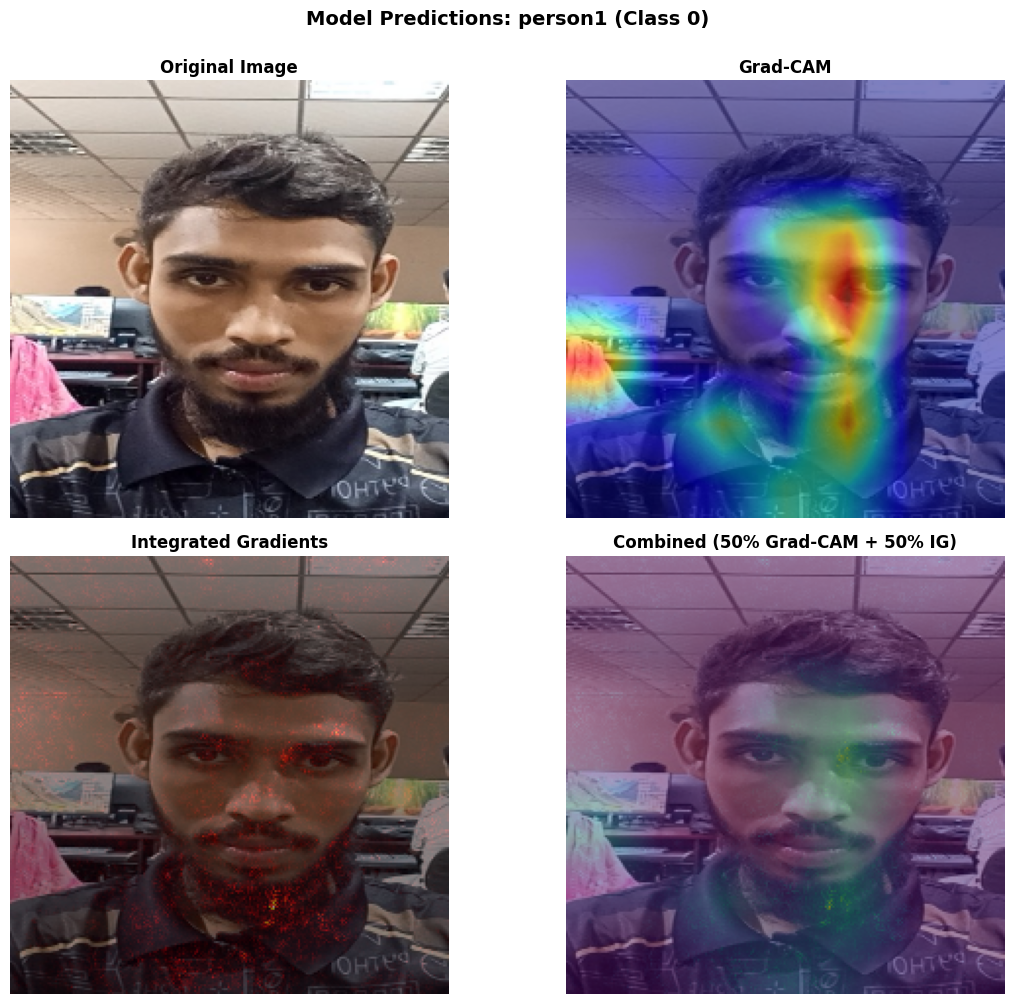


Face: ../Assignment_2/data/face_test/person2/Nazmul (1).jpg
True: person2, Predicted: person1 (29.16%)


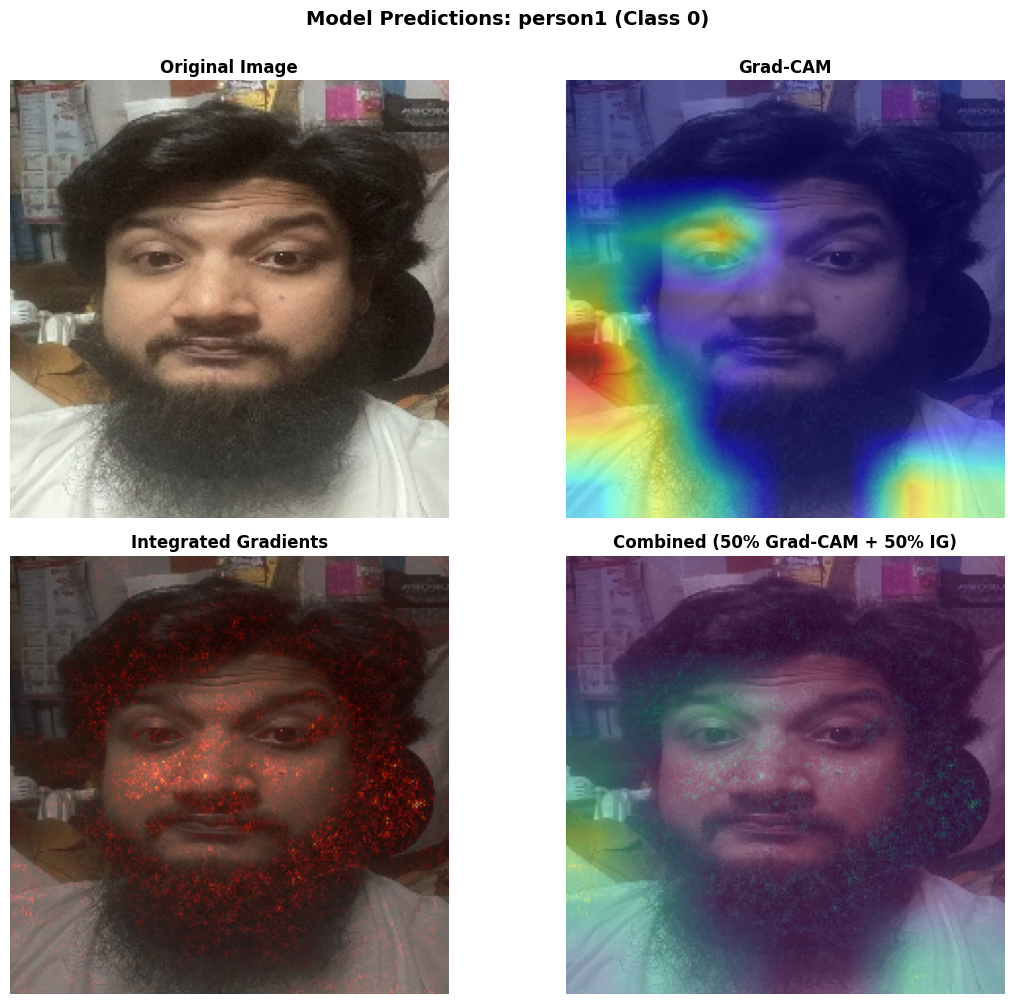


Face: ../Assignment_2/data/face_test/person3/Shawon (1).png
True: person3, Predicted: person1 (35.96%)


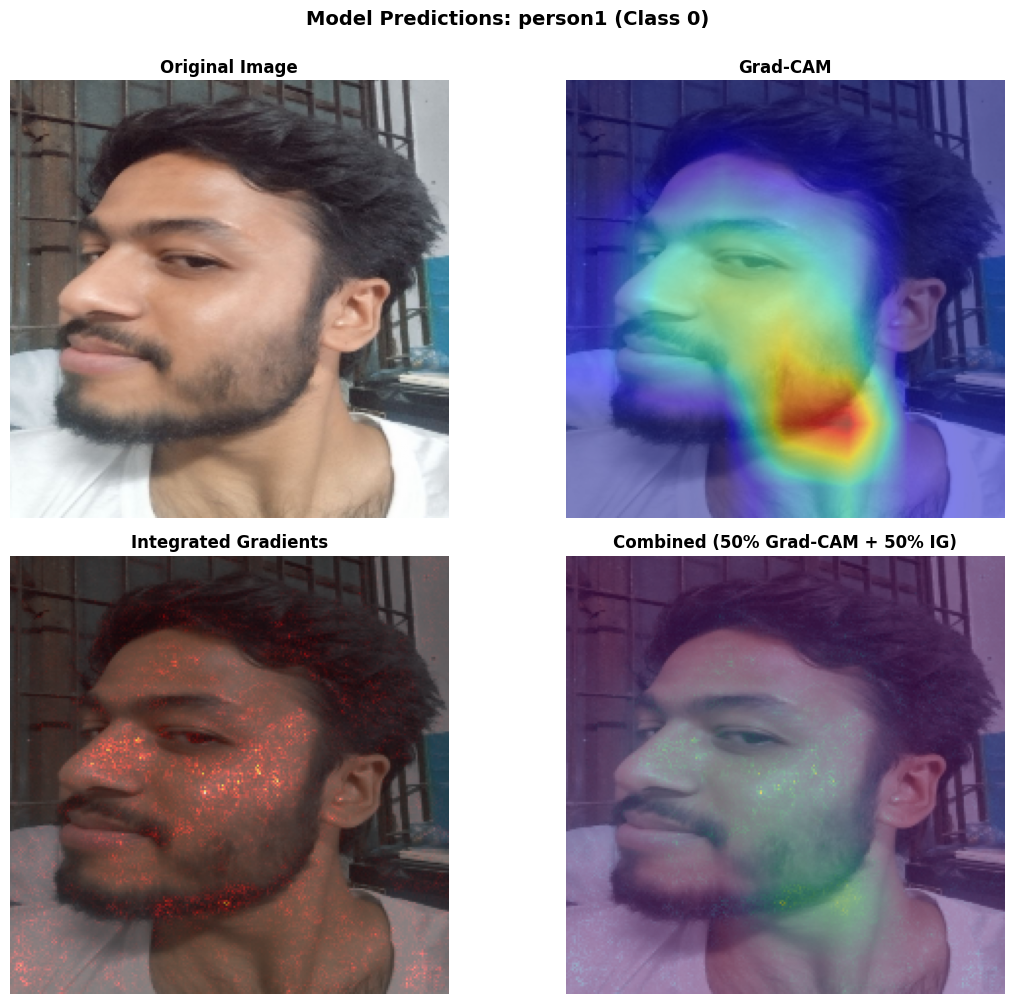

In [20]:
# Initialize explainability methods for face model
face_target_layer = face_model.layer4[-1].conv3
face_gradcam = GradCAM(face_model, face_target_layer)
face_ig = IntegratedGradients(face_model)

# Process face images
face_images_to_process = []

# Collect face images from test directory
for class_idx, class_name in enumerate(face_classes):
    class_dir = os.path.join(face_test_path, class_name)
    if os.path.exists(class_dir):
        images = [f for f in os.listdir(class_dir) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for img_file in images[:1]:  # Take 1 image per class
            face_images_to_process.append((os.path.join(class_dir, img_file), 
                                          class_idx, class_name))

print(f"Found {len(face_images_to_process)} face images to process")

# Process faces
for img_path, true_class_idx, true_class_name in face_images_to_process[:3]:  # Limit to 3
    try:
        # Load and preprocess image
        image_pil = Image.open(img_path).convert('RGB')
        image_tensor = face_transform(image_pil).unsqueeze(0).to(device)
        image_np = np.array(image_pil) / 255.0  # Normalize to [0, 1]
        
        # Get prediction
        with torch.no_grad():
            output = face_model(image_tensor)
            pred_class = output.argmax(dim=1).item()
            confidence = F.softmax(output, dim=1)[0, pred_class].item()
        
        print(f"\n{'='*60}")
        print(f"Face: {img_path}")
        print(f"True: {true_class_name}, Predicted: {face_classes[pred_class]} ({confidence:.2%})")
        print(f"{'='*60}")
        
        # Generate explanations
        face_gradcam_map = face_gradcam.generate_cam(image_tensor, pred_class)
        face_ig_map = face_ig.generate_ig(image_tensor, pred_class, steps=30)
        
        # Resize explanations to match image
        h, w = image_np.shape[:2]
        gradcam_resized = cv2.resize(face_gradcam_map, (w, h))
        ig_resized = cv2.resize(face_ig_map, (w, h))
        
        visualize_explanations(image_np, gradcam_resized, ig_resized,
                              face_classes[pred_class], pred_class)
    
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

## Comparison and Analysis of Methods

### Key Insights

In [16]:
comparison_data = {
    'Method': ['CAM', 'Grad-CAM', 'Integrated Gradients'],
    'Computation Time': ['Fast', 'Medium', 'Slow (multiple forward passes)'],
    'Interpretability': ['Good', 'Excellent', 'Excellent'],
    'Requires Gradients': ['No', 'Yes', 'Yes'],
    'Applicability': ['Last conv layer', 'Any layer', 'Whole network'],
    'Theoretical Basis': ['Feature importance', 'Gradient weighting', 'Path integration'],
    'Best For': ['Quick analysis', 'Detailed analysis', 'Feature attribution']
}

# Create comparison table
import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("EXPLAINABILITY METHODS COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Detailed explanations
print("\n📊 DETAILED ANALYSIS:\n")

print("1️⃣  CLASS ACTIVATION MAPPING (CAM):")
print("   • Works on the last convolutional layer")
print("   • Computes weighted sum of feature maps using FC layer weights")
print("   • Fast but limited to specific architecture")
print("   • Good for quick insights into what features activate for a class")
print()

print("2️⃣  GRADIENT-WEIGHTED CAM (Grad-CAM):")
print("   • Generalizes CAM using gradients")
print("   • Can be applied to any convolutional layer")
print("   • Uses gradient of class score w.r.t. feature maps as weights")
print("   • More flexible and often gives better localization")
print("   • Excellent balance between speed and interpretability")
print()

print("3️⃣  INTEGRATED GRADIENTS (IG):")
print("   • Mathematically principled attribution method")
print("   • Integrates gradients along straight-line path from baseline to input")
print("   • Satisfies key theoretical properties: Sensitivity and Implementability")
print("   • Computationally expensive (requires multiple forward/backward passes)")
print("   • Best for rigorous feature importance analysis")
print()

print("🎯 WHEN TO USE WHICH:")
print("   • Quick Model Debugging: Use Grad-CAM (fast & intuitive)")
print("   • Production Monitoring: Use Grad-CAM (good trade-off)")
print("   • Research/Publication: Use Integrated Gradients (theoretically sound)")
print("   • Model Comparison: Use all three (complementary insights)")


EXPLAINABILITY METHODS COMPARISON
              Method               Computation Time Interpretability Requires Gradients   Applicability  Theoretical Basis            Best For
                 CAM                           Fast             Good                 No Last conv layer Feature importance      Quick analysis
            Grad-CAM                         Medium        Excellent                Yes       Any layer Gradient weighting   Detailed analysis
Integrated Gradients Slow (multiple forward passes)        Excellent                Yes   Whole network   Path integration Feature attribution

📊 DETAILED ANALYSIS:

1️⃣  CLASS ACTIVATION MAPPING (CAM):
   • Works on the last convolutional layer
   • Computes weighted sum of feature maps using FC layer weights
   • Fast but limited to specific architecture
   • Good for quick insights into what features activate for a class

2️⃣  GRADIENT-WEIGHTED CAM (Grad-CAM):
   • Generalizes CAM using gradients
   • Can be applied to any conv

## Practical Applications & Best Practices

### Use Cases

In [17]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                    REAL-WORLD APPLICATIONS                                    ║
╠════════════════════════════════════════════════════════════════════════════════╣
║                                                                                ║
║  🏥 MEDICAL IMAGING                                                            ║
║     • Grad-CAM to highlight regions of tumors/abnormalities                    ║
║     • Helps radiologists understand model decisions                            ║
║     • Critical for FDA approval of AI diagnostics                              ║
║                                                                                ║
║  🚗 AUTONOMOUS DRIVING                                                         ║
║     • Integrated Gradients to identify important visual features               ║
║     • Ensures model focuses on relevant road/pedestrian features               ║
║     • Safety-critical decision verification                                    ║
║                                                                                ║
║  🔍 OBJECT DETECTION                                                           ║
║     • Grad-CAM to visualize detection regions                                  ║
║     • Verify model isn't using spurious correlations                           ║
║     • Example: Detecting dogs vs. detecting leashes?                           ║
║                                                                                ║
║  😊 FACE RECOGNITION                                                           ║
║     • Verify model uses facial features, not backgrounds                       ║
║     • Detect bias in attention patterns                                        ║
║     • Ensure fairness across different demographics                            ║
║                                                                                ║
║  🎓 MODEL DEBUGGING                                                            ║
║     • Find dataset biases (e.g., watermarks, logos)                            ║
║     • Discover shortcuts (spurious correlations)                               ║
║     • Improve model robustness                                                 ║
║                                                                                ║
╚════════════════════════════════════════════════════════════════════════════════╝

╔════════════════════════════════════════════════════════════════════════════════╗
║                    BEST PRACTICES                                              ║
╠════════════════════════════════════════════════════════════════════════════════╣
║                                                                                ║
║  1. USE MULTIPLE METHODS                                                       ║
║     • Different methods highlight different aspects                            ║
║     • Consensus across methods increases confidence                            ║
║     • Cross-validation of explanations                                         ║
║                                                                                ║
║  2. VALIDATE EXPLANATIONS                                                      ║
║     • Perturb important regions and check predictions change                   ║
║     • Use human evaluations for subjective validity                            ║
║     • Compare with domain expert expectations                                  ║
║                                                                                ║
║  3. HANDLE EDGE CASES                                                          ║
║     • Test with adversarial examples                                           ║
║     • Verify explanations for misclassified samples                            ║
║     • Check out-of-distribution inputs                                         ║
║                                                                                ║
║  4. COMPUTATIONAL EFFICIENCY                                                   ║
║     • Cache feature maps and gradients when processing batches                 ║
║     • Use GPU acceleration for Integrated Gradients                            ║
║     • Batch process multiple images together                                   ║
║                                                                                ║
║  5. DOCUMENT & COMMUNICATE                                                     ║
║     • Explain limitations of explainability methods                            ║
║     • Provide context to stakeholders                                          ║
║     • Use consistent visualization scales                                      ║
║                                                                                ║
╚════════════════════════════════════════════════════════════════════════════════╝
""")


╔════════════════════════════════════════════════════════════════════════════════╗
║                    REAL-WORLD APPLICATIONS                                    ║
╠════════════════════════════════════════════════════════════════════════════════╣
║                                                                                ║
║  🏥 MEDICAL IMAGING                                                            ║
║     • Grad-CAM to highlight regions of tumors/abnormalities                    ║
║     • Helps radiologists understand model decisions                            ║
║     • Critical for FDA approval of AI diagnostics                              ║
║                                                                                ║
║  🚗 AUTONOMOUS DRIVING                                                         ║
║     • Integrated Gradients to identify important visual features               ║
║     • Ensures model focuses on relevant road/pedestrian features               ║
║     

## Summary

### What We Implemented

1. **Class Activation Mapping (CAM)**
   - Highlights important regions using feature map weights
   - Fast and simple but architecture-dependent

2. **Grad-CAM (Gradient-weighted CAM)**
   - Uses gradients for general layer applicability
   - Best balance of speed and interpretability

3. **Integrated Gradients (IG)**
   - Theoretically principled attribution method
   - Measures pixel contribution through path integration

### Key Takeaways

- **Explainability ≠ Correctness**: High confidence doesn't mean correct decision
- **Multiple Views Matter**: Combine different methods for robust insights  
- **Domain Context**: Always validate with domain experts
- **Practical Trade-offs**: Balance between interpretability and computational cost

### Next Steps

1. Experiment with different target layers
2. Try other attribution methods: LRP, SHAP, SmoothGrad
3. Develop automated metrics for explanation quality
4. Apply to your own custom models and datasets

## References & Mathematical Formulations

### CAM Formula
$$\text{CAM}_c(x, y) = \sum_k w_k^c f_k(x, y)$$

Where:
- $w_k^c$ = weight of k-th feature map for class c (from FC layer)
- $f_k(x,y)$ = activation of k-th feature map at spatial location (x,y)

### Grad-CAM Formula
$$\text{Grad-CAM}_c(x,y) = \text{ReLU}\left(\sum_k w_k^c A_k(x,y)\right)$$
$$w_k^c = \frac{1}{Z}\sum_i\sum_j \frac{\partial y^c}{\partial A_{ij}^k}$$

Where:
- $\frac{\partial y^c}{\partial A_{ij}^k}$ = gradient of class score with respect to feature map

### Integrated Gradients Formula
$$\text{IG}_i(x) = (x_i - x_i^{\text{baseline}}) \times \int_0^1 \frac{\partial F(x^{\text{baseline}} + \alpha(x - x^{\text{baseline}}))}{\partial x_i} d\alpha$$

### Key References

1. **CAM**: Zhou et al. "Learning Deep Features for Discriminative Localization" (CVPR 2016)
2. **Grad-CAM**: Selvaraju et al. "Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization" (ICCV 2017)
3. **Integrated Gradients**: Sundararajan et al. "Axiomatic Attribution for Deep Networks" (ICML 2017)
4. **XAI Review**: Montavon et al. "Methods for Interpreting and Understanding Deep Neural Networks" (Digital Signal Processing Review 2019)